## Demo notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

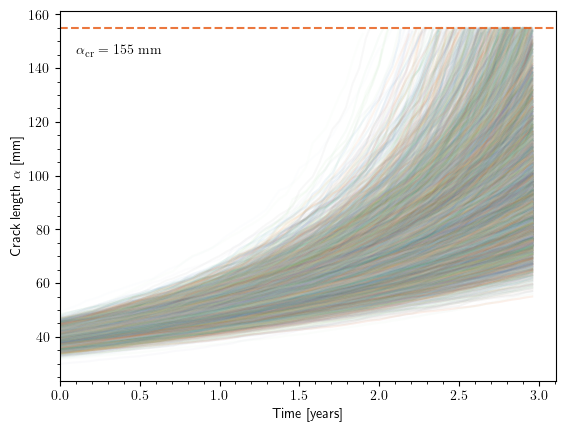

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

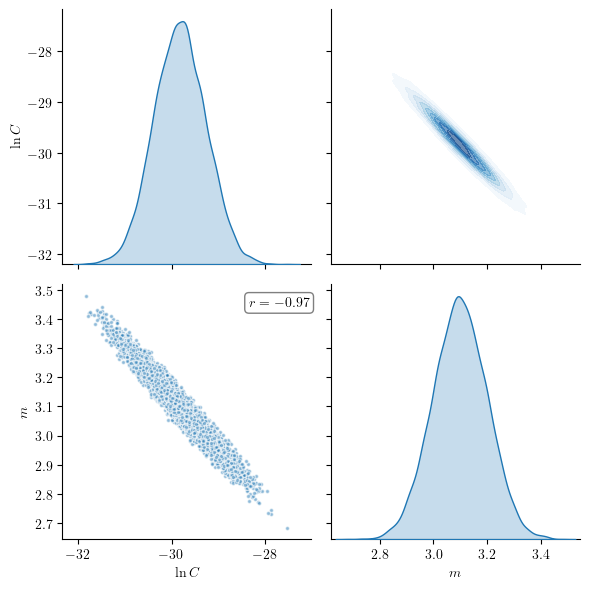

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

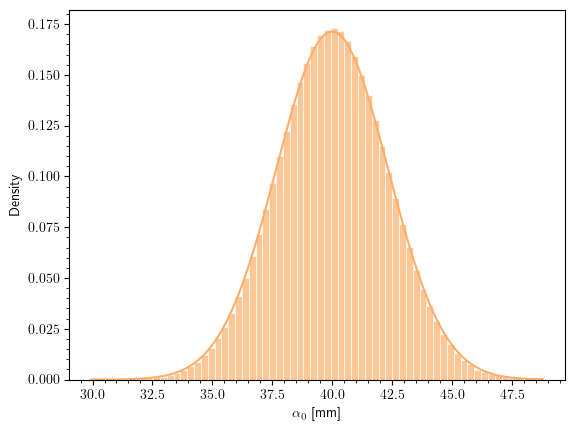

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

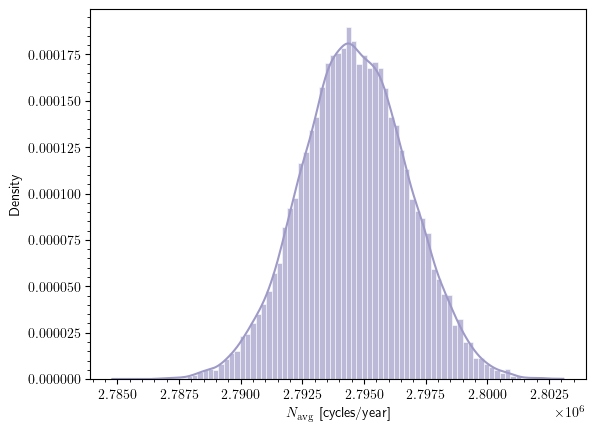

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

In [10]:
import numpy as np

print(f"Average equivalent number of cycles for an approx. 3-year span: {data['avg_cycles'].mean() * data['times'].max():.2f}")
print(f"Assuming an 8-second average period, this is approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600:.2f} hours of operation.")
print(f"Or approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600 / (365 * 24):.2f} years of operation.")

Average equivalent number of cycles for an approx. 3-year span: 8268437.54
Assuming an 8-second average period, this is approximately 18374.31 hours of operation.
Or approximately 2.10 years of operation.


In [11]:
print(f"""Based on the data, the average period is approximately:
{(3*365.25*24*60*60)/(data['avg_cycles'].mean() * data['times'].max()):.2f} seconds.""")

Based on the data, the average period is approximately:
11.45 seconds.


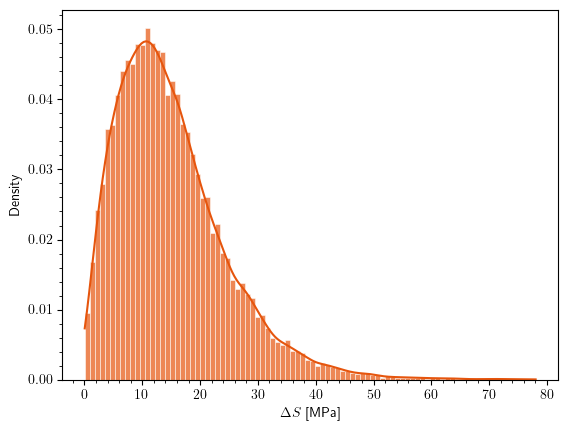

In [12]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

In [92]:
from src.visualisation import plot_paris_predictions
import numpy as np

In [93]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.mean(data["stress_ranges"][:, instances], axis=0)
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

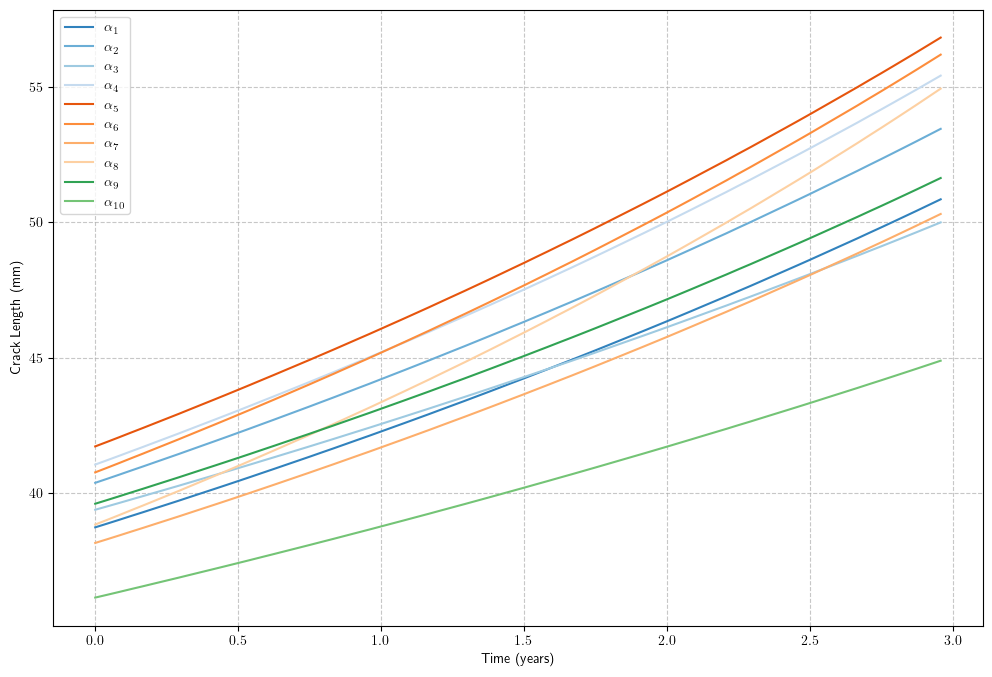

In [100]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(12, 8),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 9372:
logC: -29.0142
m: 2.9535
ds: 14.8722
navg: 2793155.5950
a0: 38.7810


Text(0.5, 1.0, 'Crack Growth for Instance 9372')

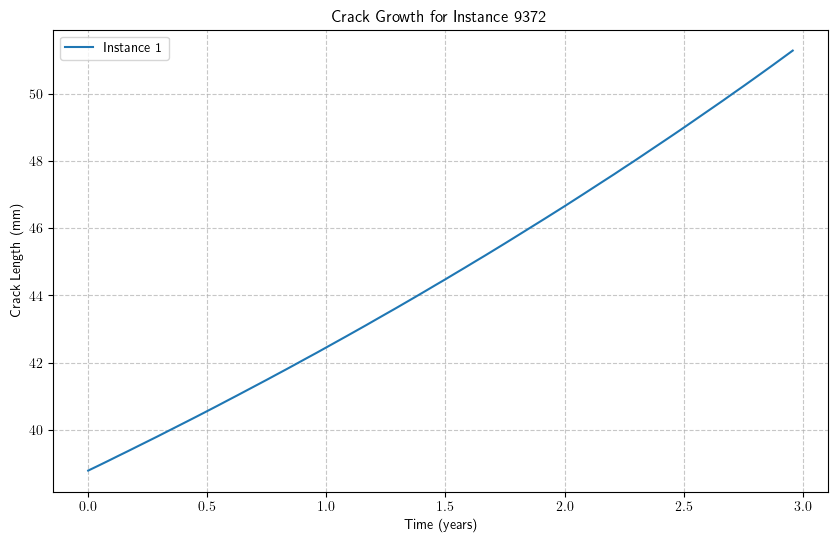

In [91]:
# Let's also test a single prediction to understand what's going on
inst = instances[0]
logc = np.log(paris_params[0][0])
m = paris_params[1][0]
ds = stress_ranges[0]
navg = n_cycles[0]
a0 = initial_crack_lengths[0]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {logc:.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions_detailed(
    paris_params=(paris_params[0][0:1], paris_params[1][0:1]),
    ds=stress_ranges[0],
    navg=n_cycles[0],
    a0=initial_crack_lengths[0],
    times=time_array,
    figsize=(10, 6)
)

ax.set_title(f"Crack Growth for Instance {inst}")

In [ ]:
# Let's also explore how different parameters affect crack growth
import matplotlib.pyplot as plt
from src.predictive_models import CrackGrowthPredictor

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = stress_ranges[0]
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Create predictor
predictor = CrackGrowthPredictor()

# Create variations of parameters
c_variations = [base_c * 0.5, base_c, base_c * 1.5]
m_variations = [base_m * 0.8, base_m, base_m * 1.2]
ds_variations = [base_ds * 0.7, base_ds, base_ds * 1.3]

# Plot effect of C parameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Effect of C
for i, c in enumerate(c_variations):
    cl = predictor.predict_crack_growth(
        logc=np.log(c),
        m=base_m,
        ds=base_ds,
        navg=base_navg,
        a0=base_a0,
        times=time_array
    )
    axes[0].plot(time_array, cl, label=f"C = {c:.2e}")
axes[0].set_title("Effect of C parameter")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Crack Length (mm)")
axes[0].grid(True)
axes[0].legend()

# Effect of m
for i, m in enumerate(m_variations):
    cl = predictor.predict_crack_growth(
        logc=np.log(base_c),
        m=m,
        ds=base_ds,
        navg=base_navg,
        a0=base_a0,
        times=time_array
    )
    axes[1].plot(time_array, cl, label=f"m = {m:.2f}")
axes[1].set_title("Effect of m parameter")
axes[1].set_xlabel("Time (years)")
axes[1].grid(True)
axes[1].legend()

# Effect of stress range
for i, ds in enumerate(ds_variations):
    cl = predictor.predict_crack_growth(
        logc=np.log(base_c),
        m=base_m,
        ds=ds,
        navg=base_navg,
        a0=base_a0,
        times=time_array
    )
    axes[2].plot(time_array, cl, label=f"ΔS = {ds:.2f}")
axes[2].set_title("Effect of stress range")
axes[2].set_xlabel("Time (years)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.savefig("parameter_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()